# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('games.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,...,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,...,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,...,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,...,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,...,1,0,1,0,0,0,0,0,150.8,322.3


## last Five row

In [4]:
df.tail()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
49995,G049996,NBA 2026,NES,Console,Nintendo,3,Sports,2002,Warner Bros. Games,Warner Bros. Games,...,1,1,0,0,0,0,0,0,28.2,87.9
49996,G049997,Kirby's Odyssey,GameCube,Console,Nintendo,6,Platform,2001,Remedy Entertainment,Remedy Entertainment,...,1,1,0,0,0,0,0,0,12.0,34.8
49997,G049998,Baldur's Gate 6,Browser,Browser,Various,0,Role-Playing,2014,Naughty Dog,Larian Studios,...,1,1,0,0,0,0,0,0,58.1,144.4
49998,G049999,Lost Ark 3,PlayStation 5,Console,Sony,9,MMORPG,2021,Larian Studios,Larian Studios,...,1,0,1,1,0,0,0,0,242.7,630.8
49999,G050000,FIFA 2023,Mobile (iOS),Mobile,Apple,0,Sports,2023,Larian Studios,Larian Studios,...,1,0,1,1,0,0,0,0,18.6,48.2


## Shape of our dataset

In [5]:
df.shape

(50000, 35)

## List out all columns

In [6]:
df.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                        int64
user_score                            float64
critic_review_count                     int64
user_review_count                       int64
na_sales_million                      float64
eu_sales_million                      float64
jp_sales_million                      float64
other_sales_million                   float64
global_sales_million              

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   game_id                             50000 non-null  object 
 1   title                               50000 non-null  object 
 2   platform                            50000 non-null  object 
 3   platform_type                       50000 non-null  object 
 4   platform_maker                      50000 non-null  object 
 5   platform_generation                 50000 non-null  int64  
 6   genre                               50000 non-null  object 
 7   year                                50000 non-null  int64  
 8   publisher                           50000 non-null  object 
 9   developer                           50000 non-null  object 
 10  publisher_region                    50000 non-null  object 
 11  publisher_tier                      50000

## Check Null Value

In [9]:
df.isnull().sum()

game_id                               0
title                                 0
platform                              0
platform_type                         0
platform_maker                        0
platform_generation                   0
genre                                 0
year                                  0
publisher                             0
developer                             0
publisher_region                      0
publisher_tier                        0
esrb_rating                           0
metacritic_score                      0
user_score                            0
critic_review_count                   0
user_review_count                     0
na_sales_million                      0
eu_sales_million                      0
jp_sales_million                      0
other_sales_million                   0
global_sales_million                  0
estimated_revenue_million_usd         0
launch_price_usd                      0
is_sequel                             0


## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,platform_generation,year,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,4.397120,2007.479640,74.046480,7.407888,27.290160,470.612300,11.946759,7.732016,3.370298,2.985665,...,0.506960,0.623140,0.310980,0.065020,0.036520,0.024420,0.044640,0.006760,24.84839,87.036108
std,3.256757,11.673832,8.626383,1.160381,26.261779,894.567299,20.717035,13.477750,7.439700,5.634561,...,0.499957,0.484604,0.462899,0.246564,0.187582,0.154351,0.206514,0.081942,34.73811,126.802256
min,0.000000,1985.000000,37.000000,2.200000,0.000000,0.000000,0.030000,0.010000,0.000000,0.010000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,2.000000
25%,0.000000,1998.000000,68.000000,6.600000,11.000000,91.000000,2.420000,1.510000,0.400000,0.540000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.00000,29.400000
50%,5.000000,2008.000000,74.000000,7.400000,20.000000,221.000000,5.940000,3.760000,1.210000,1.380000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.20000,46.100000
75%,7.000000,2017.000000,80.000000,8.200000,34.000000,515.000000,13.420000,8.632500,3.330000,3.260000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.10000,85.200000
max,10.000000,2026.000000,99.000000,10.000000,636.000000,39129.000000,769.070000,389.100000,251.210000,300.560000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,377.50000,1685.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

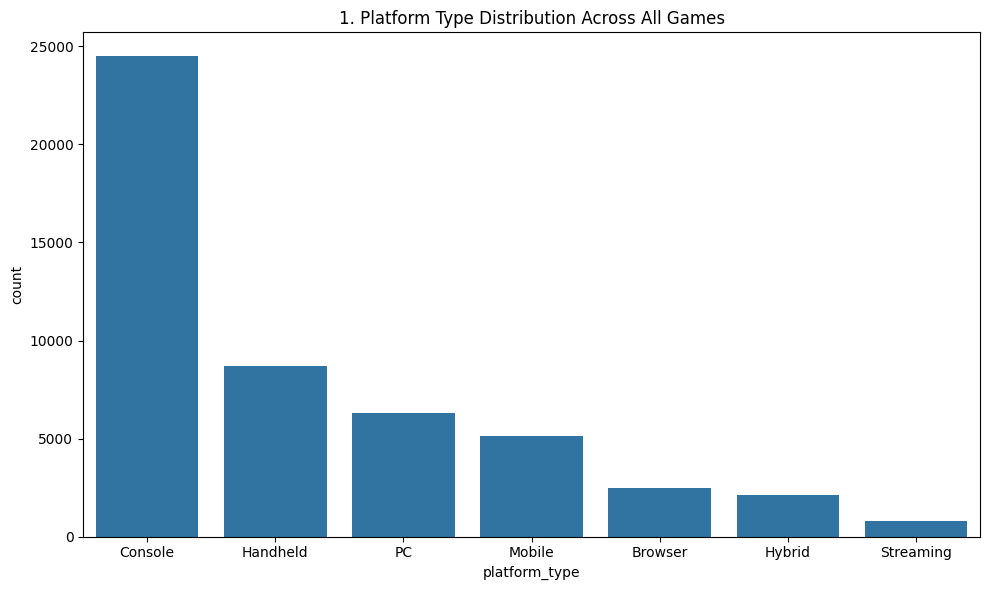

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='platform_type', order=df['platform_type'].value_counts().index)
plt.title(f'{plot_no}. Platform Type Distribution Across All Games')
show_fig()
plot_no += 1

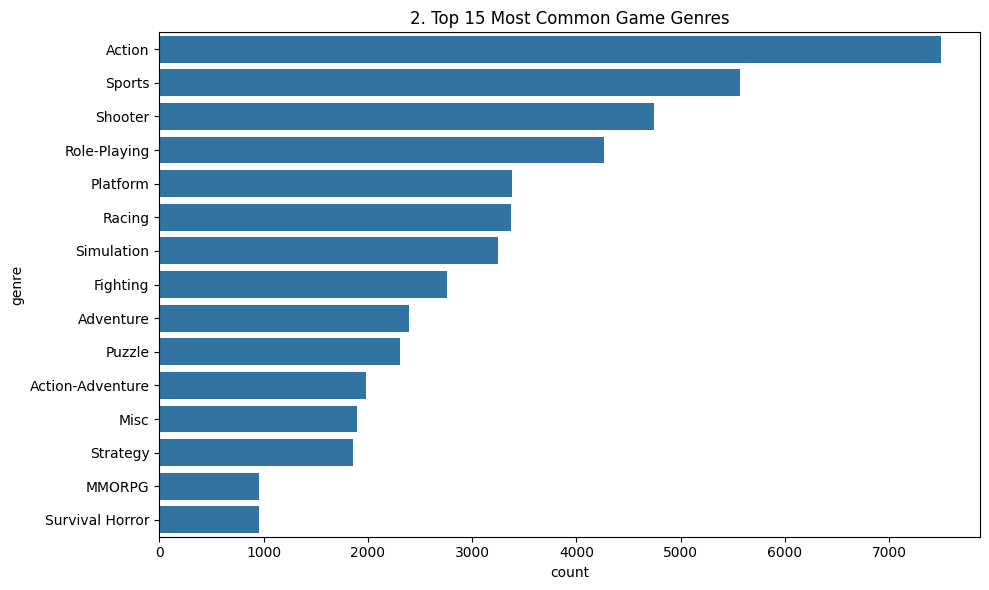

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().head(15).index)
plt.title(f'{plot_no}. Top 15 Most Common Game Genres')
show_fig()
plot_no += 1

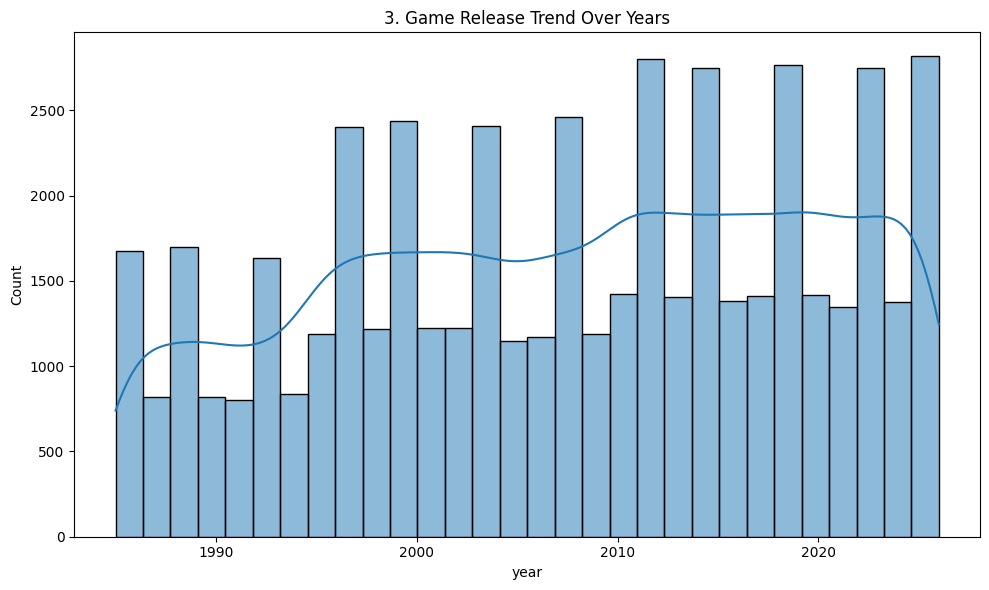

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='year', bins=30, kde=True)
plt.title(f'{plot_no}. Game Release Trend Over Years')
show_fig()
plot_no += 1

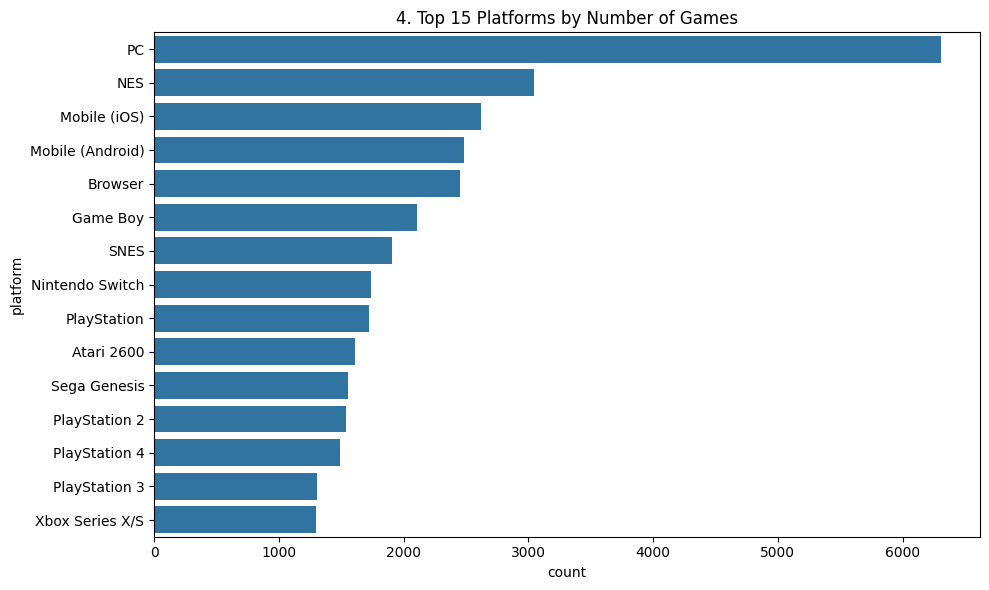

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='platform', order=df['platform'].value_counts().head(15).index)
plt.title(f'{plot_no}. Top 15 Platforms by Number of Games')
show_fig()
plot_no += 1

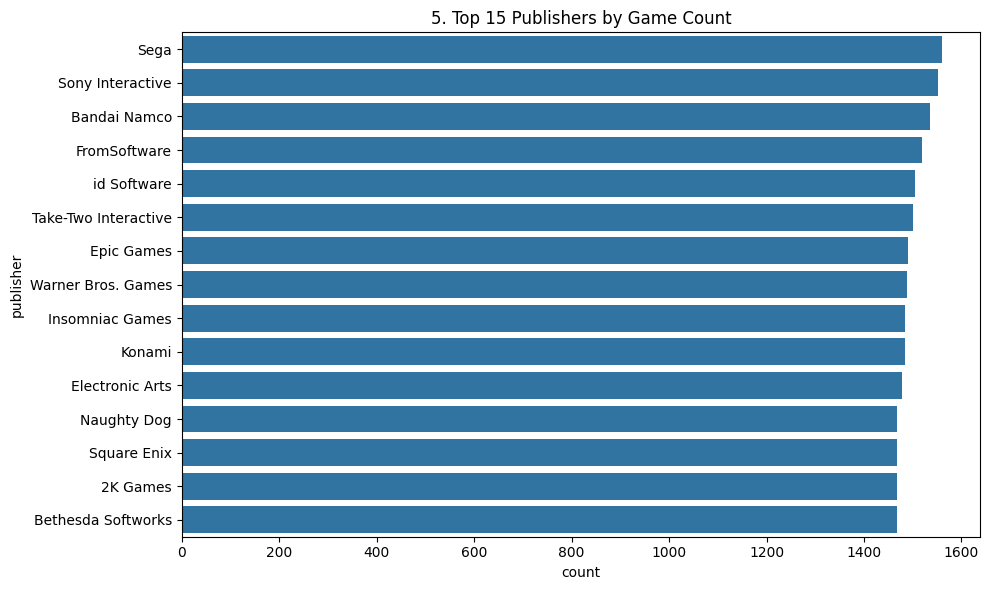

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='publisher', order=df['publisher'].value_counts().head(15).index)
plt.title(f'{plot_no}. Top 15 Publishers by Game Count')
show_fig()
plot_no += 1

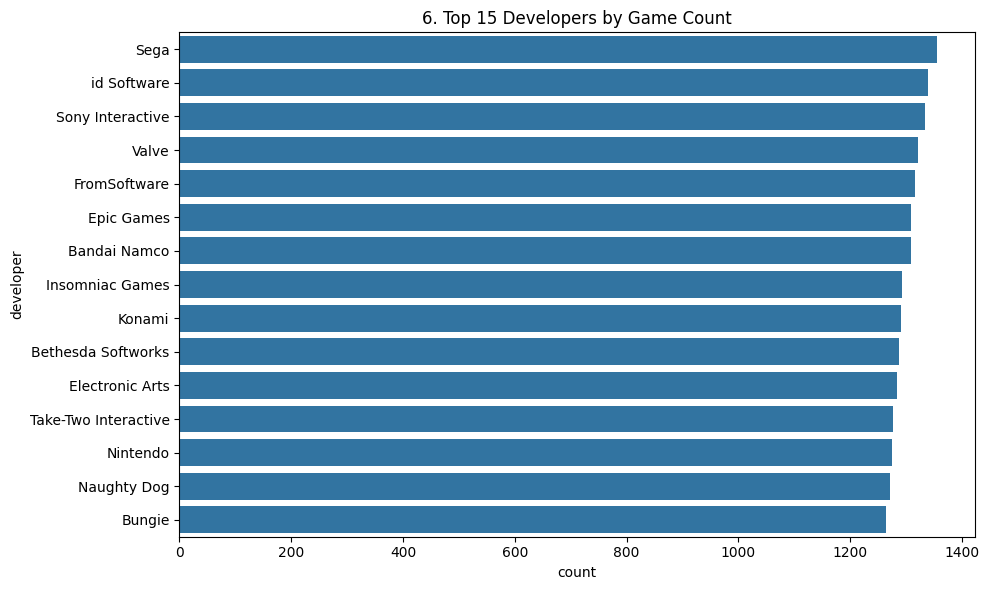

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='developer', order=df['developer'].value_counts().head(15).index)
plt.title(f'{plot_no}. Top 15 Developers by Game Count')
show_fig()
plot_no += 1

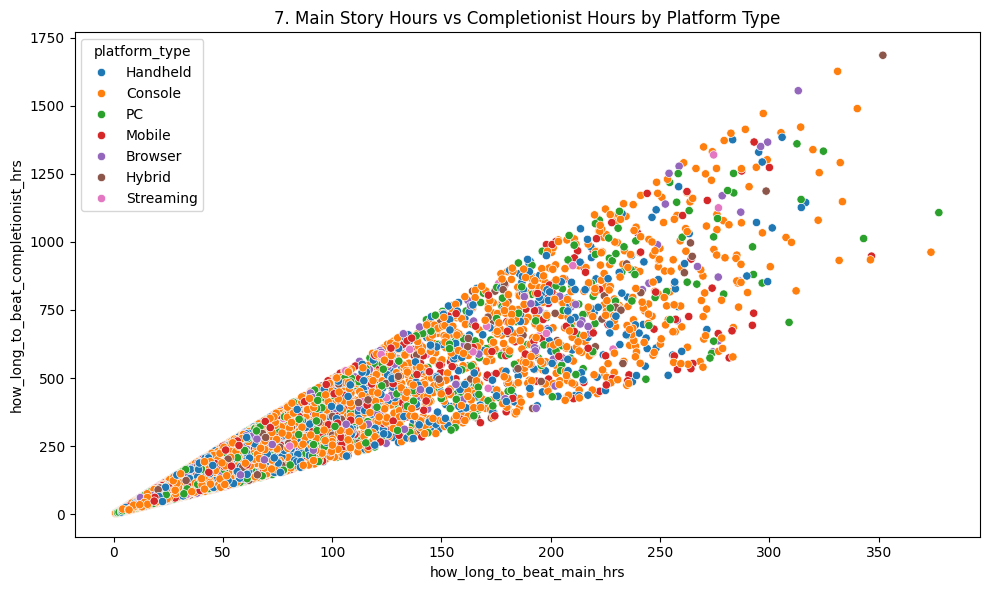

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='how_long_to_beat_main_hrs', y='how_long_to_beat_completionist_hrs', hue='platform_type')
plt.title(f'{plot_no}. Main Story Hours vs Completionist Hours by Platform Type')
show_fig()
plot_no += 1

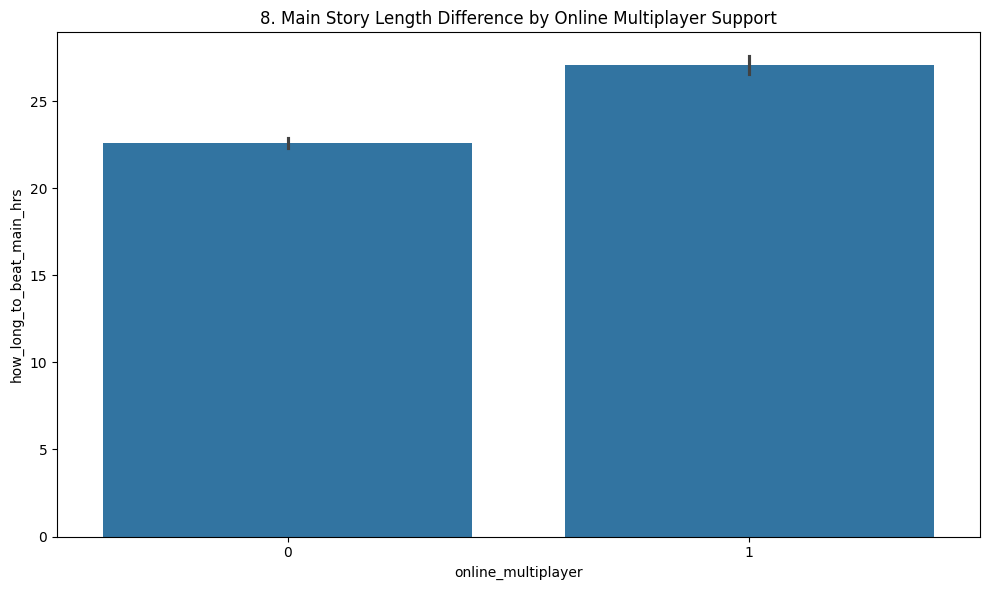

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='online_multiplayer', y='how_long_to_beat_main_hrs')
plt.title(f'{plot_no}. Main Story Length Difference by Online Multiplayer Support')
show_fig()
plot_no += 1

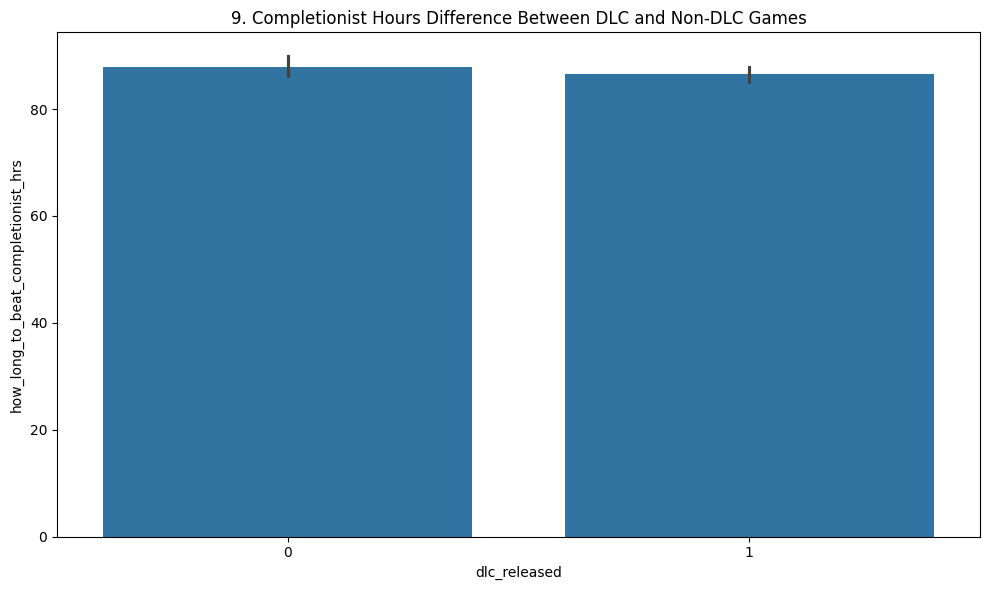

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='dlc_released', y='how_long_to_beat_completionist_hrs')
plt.title(f'{plot_no}. Completionist Hours Difference Between DLC and Non-DLC Games')
show_fig()
plot_no += 1

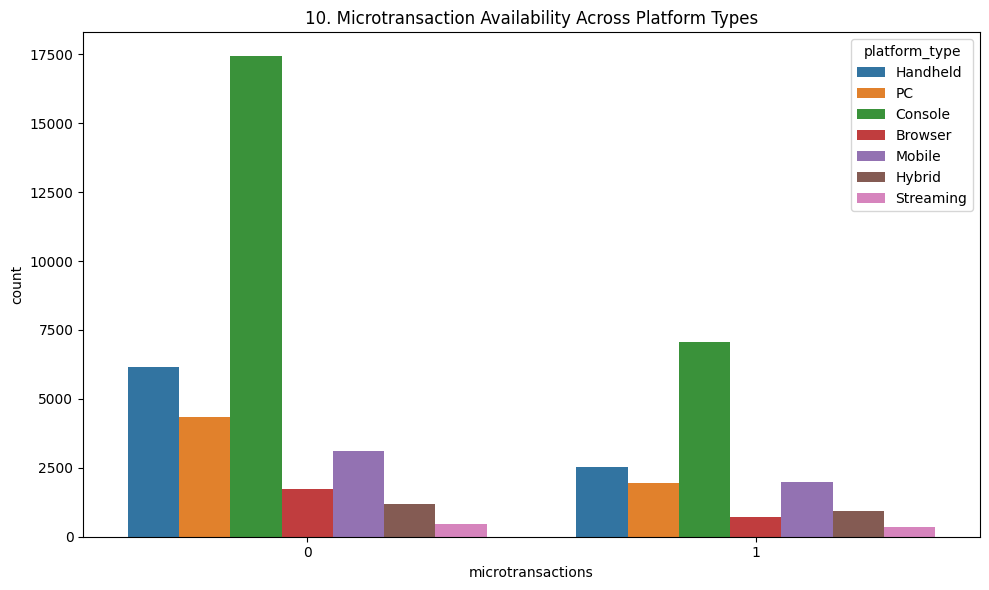

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='microtransactions', hue='platform_type')
plt.title(f'{plot_no}. Microtransaction Availability Across Platform Types')
show_fig()
plot_no += 1

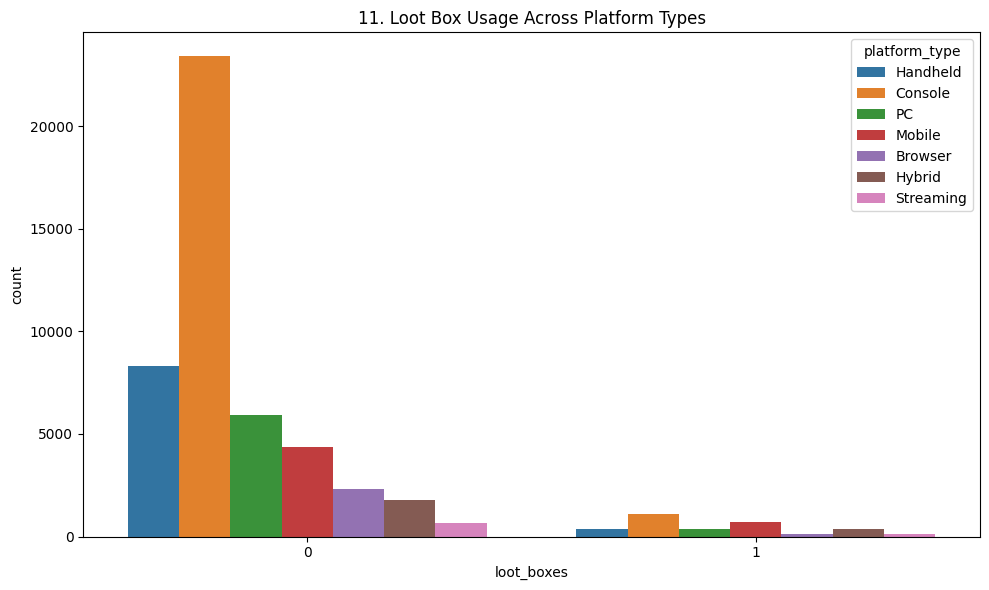

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loot_boxes', hue='platform_type')
plt.title(f'{plot_no}. Loot Box Usage Across Platform Types')
show_fig()
plot_no += 1

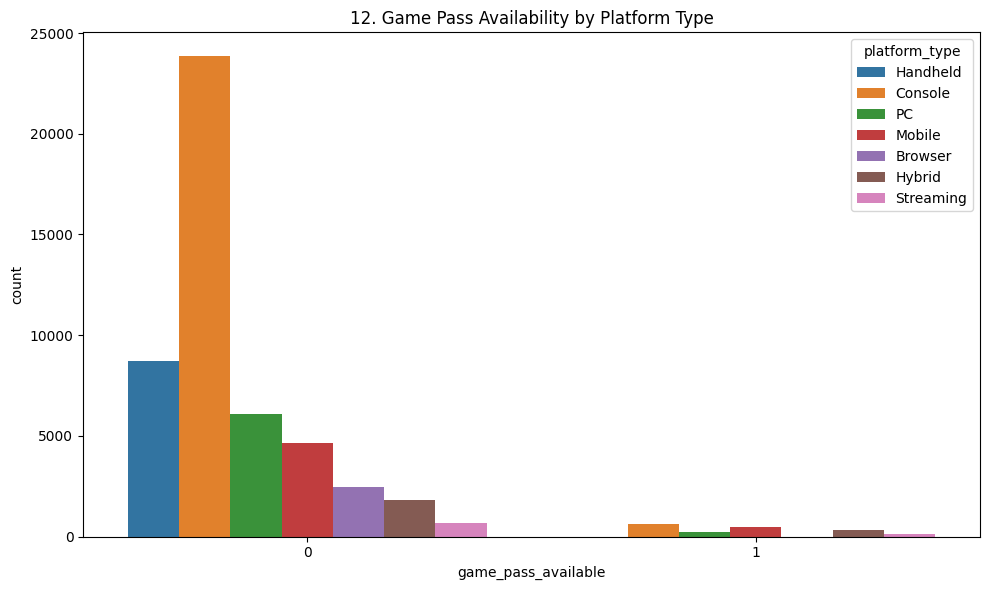

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='game_pass_available', hue='platform_type')
plt.title(f'{plot_no}. Game Pass Availability by Platform Type')
show_fig()
plot_no += 1

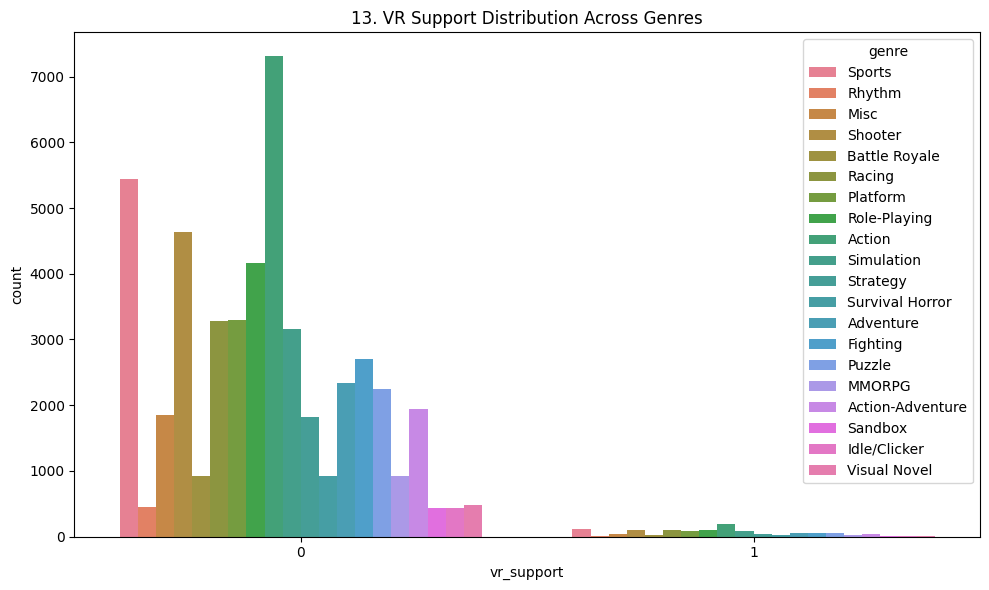

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='vr_support', hue='genre')
plt.title(f'{plot_no}. VR Support Distribution Across Genres')
show_fig()
plot_no += 1

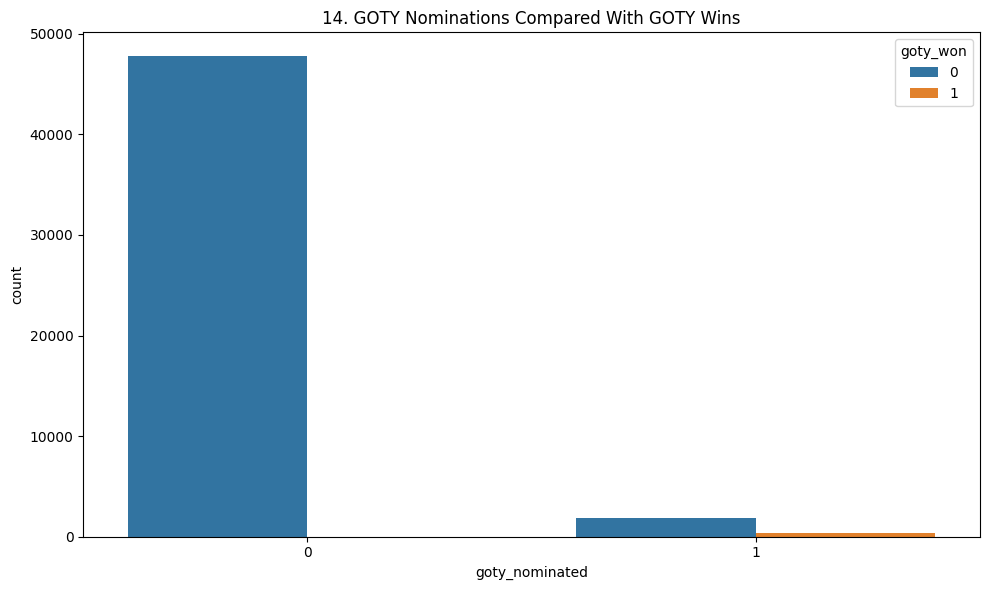

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='goty_nominated', hue='goty_won')
plt.title(f'{plot_no}. GOTY Nominations Compared With GOTY Wins')
show_fig()
plot_no += 1

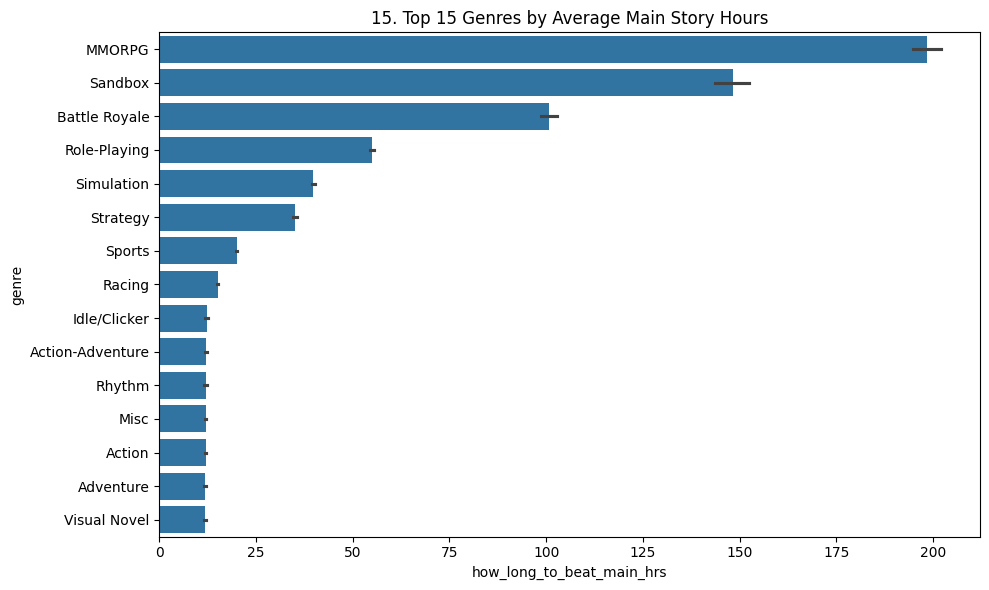

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, y='genre', x='how_long_to_beat_main_hrs', order=df.groupby('genre')['how_long_to_beat_main_hrs'].mean().sort_values(ascending=False).head(15).index)
plt.title(f'{plot_no}. Top 15 Genres by Average Main Story Hours')
show_fig()
plot_no += 1

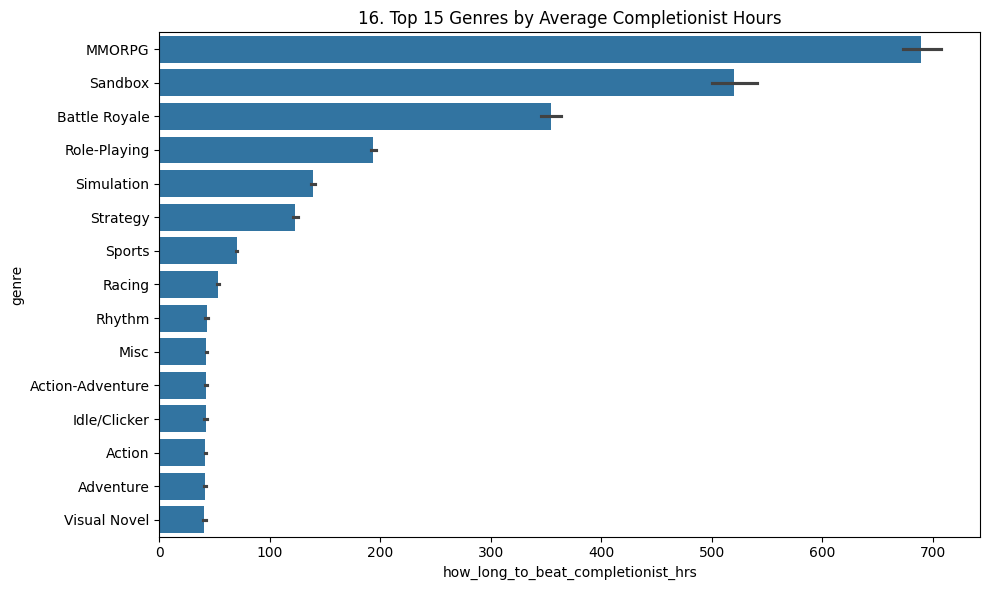

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, y='genre', x='how_long_to_beat_completionist_hrs', order=df.groupby('genre')['how_long_to_beat_completionist_hrs'].mean().sort_values(ascending=False).head(15).index)
plt.title(f'{plot_no}. Top 15 Genres by Average Completionist Hours')
show_fig()
plot_no += 1

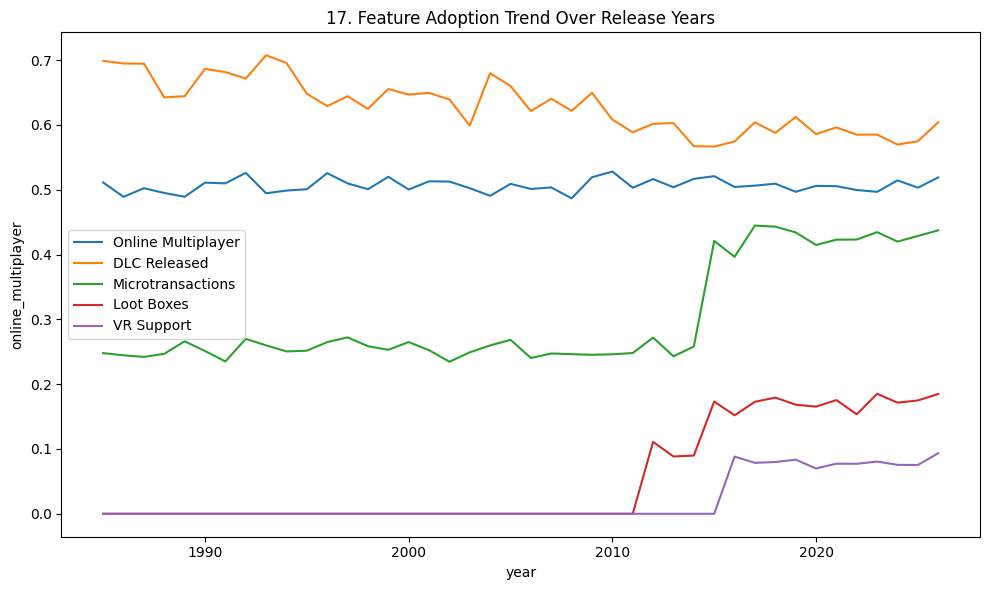

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('year')[['online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'vr_support']].mean().reset_index(), x='year', y='online_multiplayer', label='Online Multiplayer')
sns.lineplot(data=df.groupby('year')[['online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'vr_support']].mean().reset_index(), x='year', y='dlc_released', label='DLC Released')
sns.lineplot(data=df.groupby('year')[['online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'vr_support']].mean().reset_index(), x='year', y='microtransactions', label='Microtransactions')
sns.lineplot(data=df.groupby('year')[['online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'vr_support']].mean().reset_index(), x='year', y='loot_boxes', label='Loot Boxes')
sns.lineplot(data=df.groupby('year')[['online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'vr_support']].mean().reset_index(), x='year', y='vr_support', label='VR Support')
plt.title(f'{plot_no}. Feature Adoption Trend Over Release Years')
show_fig()
plot_no += 1

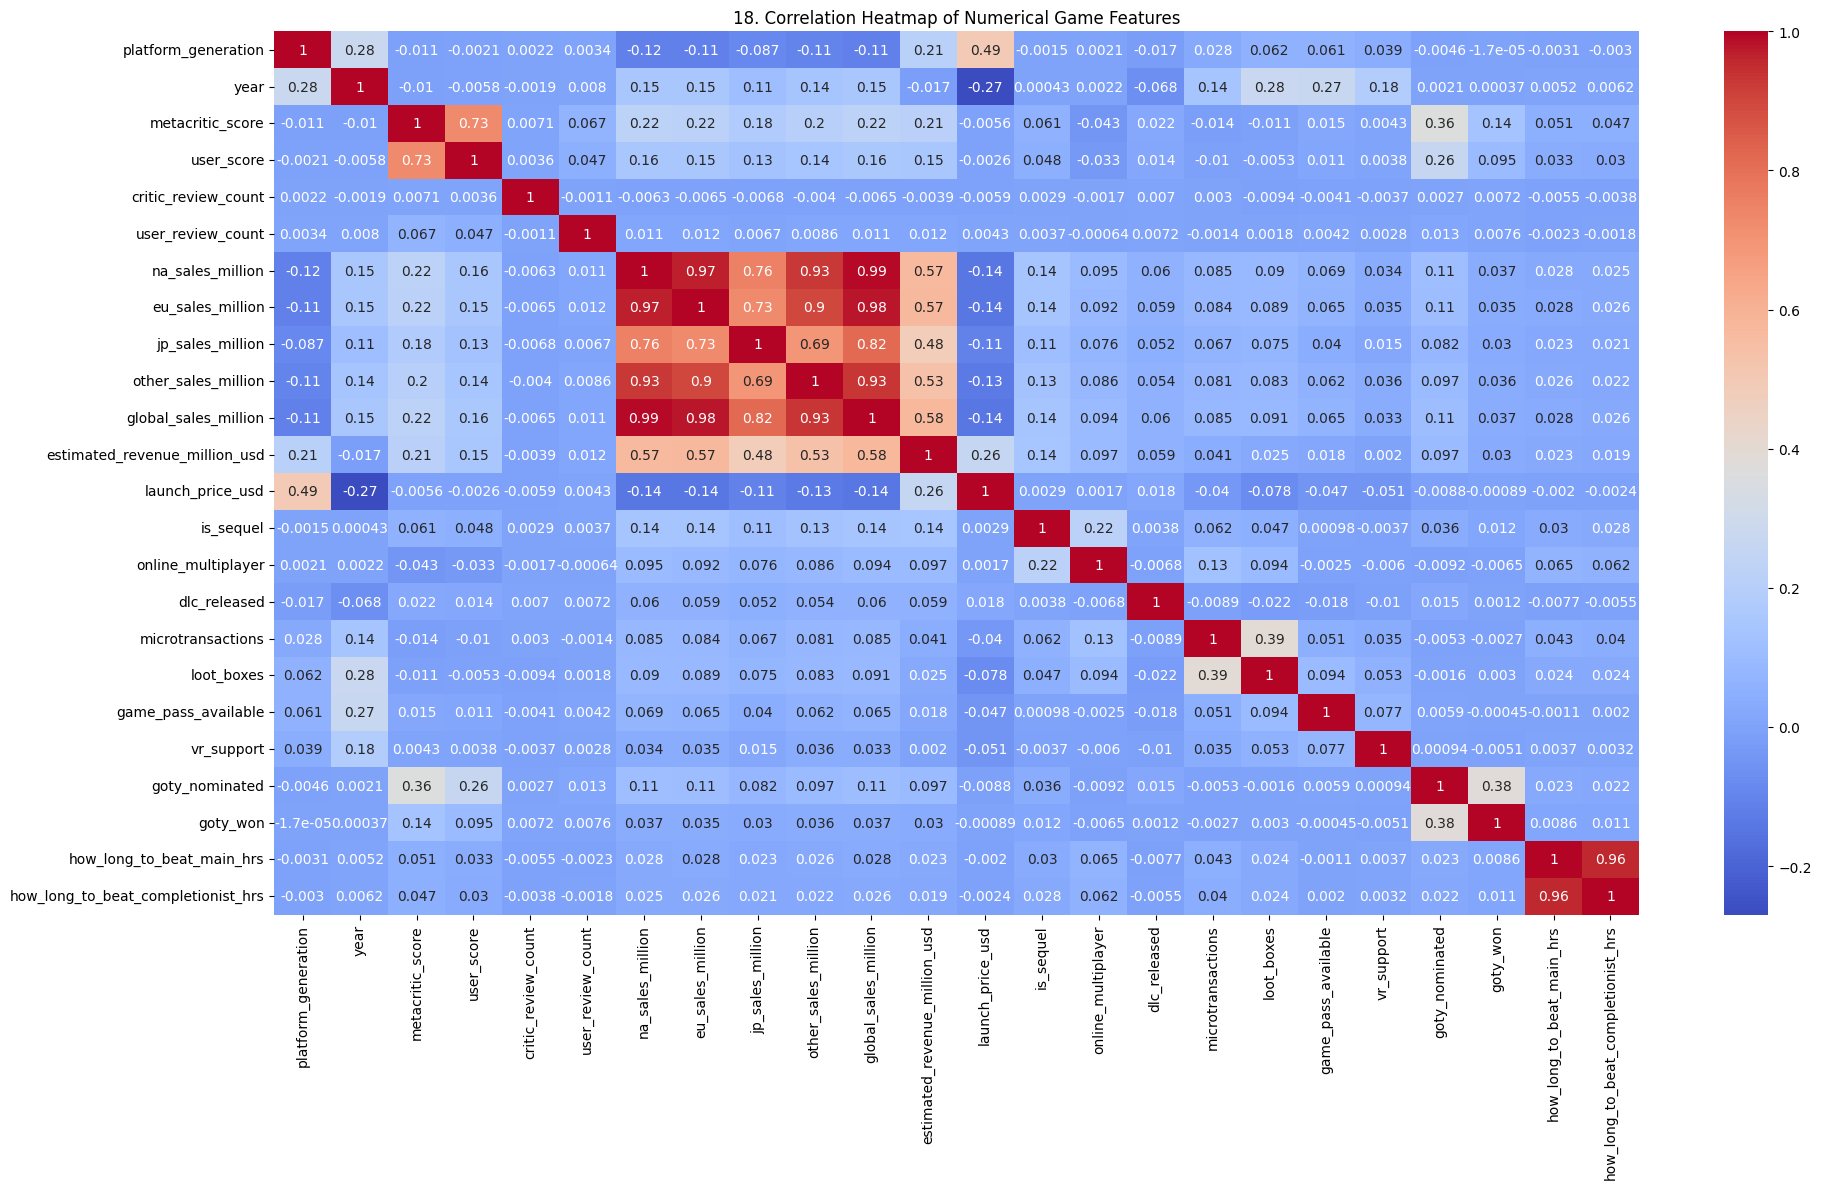

In [30]:
fig = plt.figure(figsize=(20, 12))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Game Features')
show_fig()
plot_no += 1

# Model Training

## select different target column

In [31]:
target = 'platform_type'

## select meaningful non-leakage features

In [32]:
features = [
    'platform_generation',
    'year',
    'genre',
    'publisher',
    'developer',
    'metacritic_score',
    'user_score',
    'critic_review_count',
    'user_review_count',
    'na_sales_million',
    'eu_sales_million',
    'jp_sales_million',
    'other_sales_million',
    'global_sales_million',
    'estimated_revenue_million_usd',
    'launch_price_usd',
    'is_sequel',
    'online_multiplayer',
    'dlc_released',
    'microtransactions',
    'loot_boxes',
    'game_pass_available',
    'vr_support',
    'goty_nominated',
    'goty_won',
    'how_long_to_beat_main_hrs',
    'how_long_to_beat_completionist_hrs'
]

## create feature and target data

In [33]:
X = df[[col for col in features if col in df.columns]]
y = df[target]

## encode target labels

In [34]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

## detect numerical and categorical columns

In [35]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## create numerical preprocessing

In [36]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## create categorical preprocessing

In [37]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## combine preprocessing

In [38]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## create supervised classification model

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=5,
        gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
])

## split data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## train model

In [41]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## predict test data

In [42]:
y_pred = model.predict(X_test)

## print accuracy and report

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy Score: 0.8813

Classification Report:
               precision    recall  f1-score   support

     Browser       0.83      0.89      0.86       491
     Console       0.96      0.83      0.89      4899
    Handheld       0.76      0.92      0.83      1741
      Hybrid       0.52      0.89      0.66       428
      Mobile       0.93      0.91      0.92      1021
          PC       1.00      0.99      0.99      1261
   Streaming       1.00      0.95      0.97       159

    accuracy                           0.88     10000
   macro avg       0.86      0.91      0.88     10000
weighted avg       0.90      0.88      0.89     10000



## create confusion matrix

In [44]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

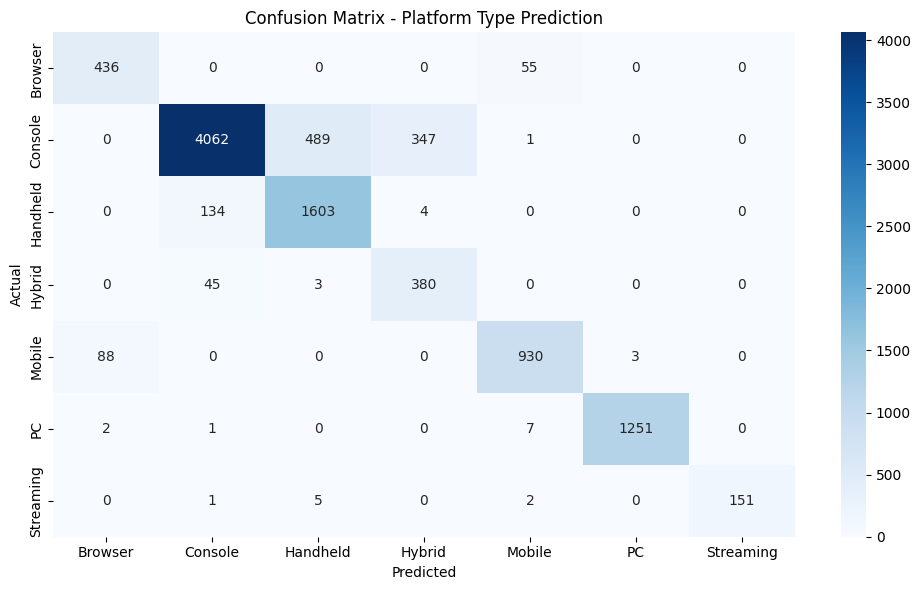

In [45]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Platform Type Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()